In [1]:
import pandas as pd

# Kaggle training data: one row per house sold in Ames, Iowa (2006-2010)
# the notebook sits in notebooks/, so "../" goes up one folder to reach data/
df = pd.read_csv("../data/train.csv")

# (rows, columns) -> rows are houses, columns are features + SalePrice
print(df.shape)

# first 5 houses, just to see what the data looks like
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**What I see**

- 1460 houses and 81 columns: Id, 79 features and SalePrice (the target).
- Mix of number columns (LotArea, LotFrontage, PoolArea) and text columns (MSZoning, Street, LotShape).
- MSSubClass looks like a number but it's a house-type code (20 = 1-story 1946+, 60 = 2-story 1946+). Treat it as a category, not a number.
- Alley, PoolQC, Fence, MiscFeature are NaN for these houses. Per data_description.txt, NA here means "no alley / no pool / no fence", so it's not really missing. Fill with "None" later.
- LotFrontage shows decimals (65.0), so it probably has real missing values. Check with df.info().
- Id is just a row number. Drop it before modelling.

In [2]:
# column name, how many non-empty values it has, and its type
# int/float = numbers, object = text
# any count below 1460 means that column has NaN somewhere
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
# count NaN in every column, biggest first
missing = df.isna().sum().sort_values(ascending=False)

# drop the columns that have no NaN at all
missing = missing[missing > 0]

# as a % of all 1460 houses, so columns are easy to compare
missing_pct = (missing / len(df) * 100).round(1)

print(len(missing), "columns have NaN")
missing_pct

19 columns have NaN


PoolQC          99.5
MiscFeature     96.3
Alley           93.8
Fence           80.8
MasVnrType      59.7
FireplaceQu     47.3
LotFrontage     17.7
GarageQual       5.5
GarageFinish     5.5
GarageType       5.5
GarageYrBlt      5.5
GarageCond       5.5
BsmtFinType2     2.6
BsmtExposure     2.6
BsmtCond         2.5
BsmtQual         2.5
BsmtFinType1     2.5
MasVnrArea       0.5
Electrical       0.1
dtype: float64

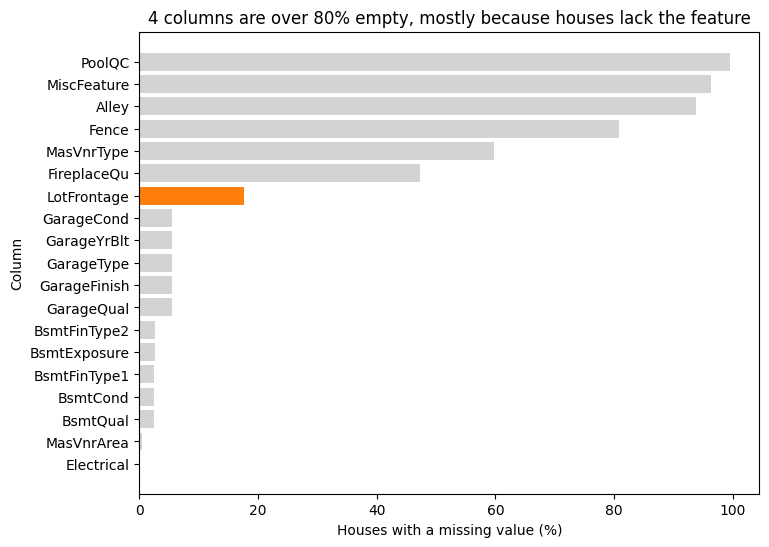

In [4]:
import matplotlib.pyplot as plt

# barh draws bottom-up, so sort small to big to get the biggest bar on top
plot_data = missing_pct.sort_values()

# orange = truly unknown value, grey = NaN just means "house doesn't have it"
colors = ["tab:orange" if col == "LotFrontage" else "lightgrey" for col in plot_data.index]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(plot_data.index, plot_data.values, color=colors)
ax.set_title("4 columns are over 80% empty, mostly because houses lack the feature")
ax.set_xlabel("Houses with a missing value (%)")
ax.set_ylabel("Column")
plt.show()


### Explore the data

In [5]:
# SalePrice is what we predict, in US dollars
# mean vs median tells us early if the prices are lopsided
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

**What I see**
- Prices go from about $35k to $755k.
- Mean (~$181k) is higher than the median ($163k), so a few expensive houses pull the average up.

### Histogram of the target

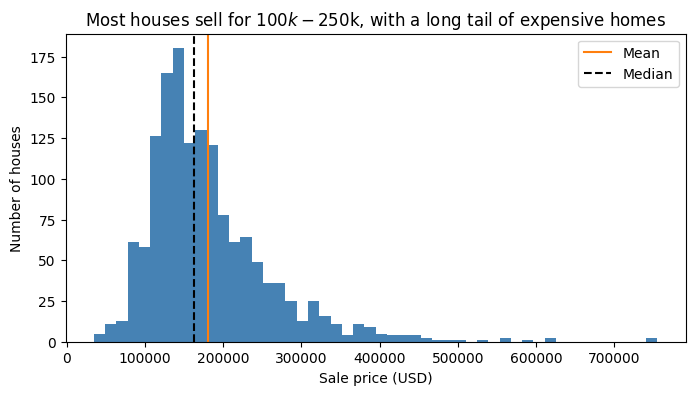

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["SalePrice"], bins=50, color="steelblue")

# lines for mean and median, to show the gap between them
ax.axvline(df["SalePrice"].mean(), color="tab:orange", label="Mean")
ax.axvline(df["SalePrice"].median(), color="black", linestyle="--", label="Median")

ax.set_title("Most houses sell for $100k-$250k, with a long tail of expensive homes")
ax.set_xlabel("Sale price (USD)")
ax.set_ylabel("Number of houses")
ax.legend()
plt.show()

**What I see**
- Right-skewed: a big hump on the left and a long thin tail to the right.
- Linear models work better when the target is closer to a bell shape. This is the reason to try a log transform.

### Measure the skew, before and after log

In [8]:
import numpy as np

# skew = 0 means balanced; above 1 means a long right tail
# log1p = log(1 + x); it squeezes big values more than small ones
print("Skew before log:", round(df["SalePrice"].skew(), 2))
print("Skew after log: ", round(np.log1p(df["SalePrice"]).skew(), 2))

Skew before log: 1.88
Skew after log:  0.12


**What I see**
- Skew drops from about 1.88 to about 0.12 after the log, so it's almost balanced.
- Bonus: Kaggle scores this competition with RMSE on log price, so a log target matches how the model is judged.

### Histogram after log

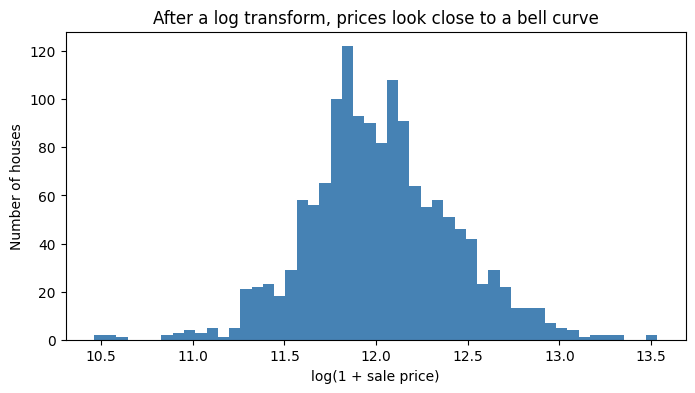

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(df["SalePrice"]), bins=50, color="steelblue")
ax.set_title("After a log transform, prices look close to a bell curve")
ax.set_xlabel("log(1 + sale price)")
ax.set_ylabel("Number of houses")
plt.show()

**What I see**
- The long tail is gone. The shape is roughly symmetric.
- Decision: the models will predict log price, and I convert back to dollars with np.expm1 at the end.

### Which number columns move with price?

In [10]:
# correlation of every number column with SalePrice (-1 to +1)
# drop SalePrice itself, since it always correlates 1.0 with itself
corr = df.select_dtypes("number").corr()["SalePrice"].drop("SalePrice")
corr.sort_values(ascending=False).head(10)

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

### Bar chart of the top 10

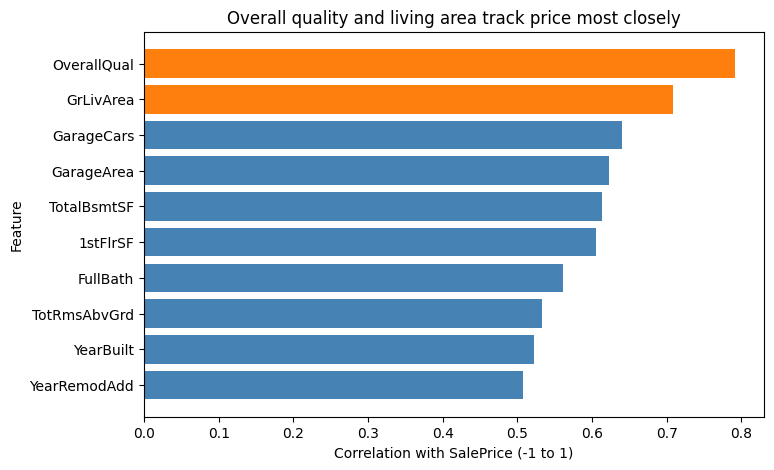

In [11]:
# biggest on top, and orange for the two strongest
top10 = corr.sort_values(ascending=False).head(10).sort_values()
colors = ["tab:orange" if v > 0.7 else "steelblue" for v in top10.values]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top10.index, top10.values, color=colors)
ax.set_title("Overall quality and living area track price most closely")
ax.set_xlabel("Correlation with SalePrice (-1 to 1)")
ax.set_ylabel("Feature")
plt.show()

**What I see**
- OverallQual (~0.79) and GrLivArea (~0.71) are the strongest.
- GarageCars and GarageArea are both high, but they say the same thing (bigger garage). Same for TotalBsmtSF and 1stFlrSF. Pairs like this are called multicollinearity; Ridge handles them better than plain linear regression.

### Scatter plot, living area vs price

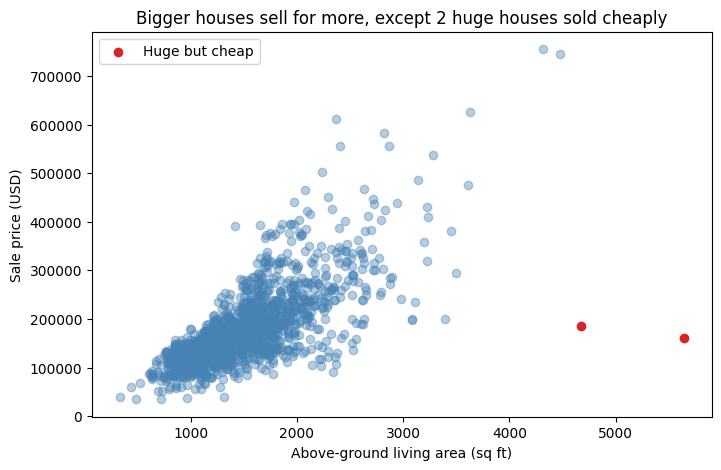

In [12]:
# very large houses that sold cheap; the dataset's author recommends removing them
odd = (df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df.loc[~odd, "GrLivArea"], df.loc[~odd, "SalePrice"], alpha=0.4, color="steelblue")
ax.scatter(df.loc[odd, "GrLivArea"], df.loc[odd, "SalePrice"], color="tab:red", label="Huge but cheap")
ax.set_title("Bigger houses sell for more, except 2 huge houses sold cheaply")
ax.set_xlabel("Above-ground living area (sq ft)")
ax.set_ylabel("Sale price (USD)")
ax.legend()
plt.show()

In [13]:
# check what makes them odd before deciding to drop them
df.loc[odd, ["Id", "GrLivArea", "SalePrice", "SaleCondition", "Neighborhood"]]

,Id,GrLivArea,SalePrice,SaleCondition,Neighborhood
523,524,4676,184750,Partial,Edwards
1298,1299,5642,160000,Partial,Edwards


**What I see**
- Clear upward trend: more living area, higher price.
- 2 houses above 4000 sq ft sold far below the trend. Their SaleCondition explains why they're unusual sales.
- Decision: remove these 2 rows before training, because they would pull the line down for all big houses.

### Box plot, price by quality grade

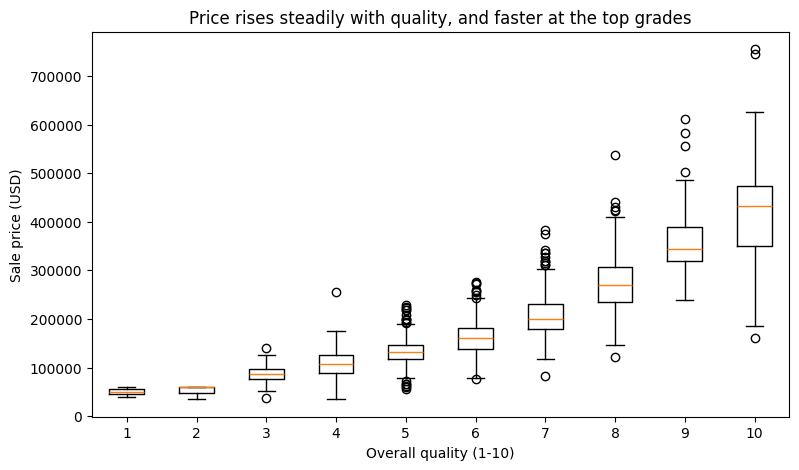

In [14]:
# one box of prices for each quality grade (1 = very poor, 10 = very excellent)
levels = sorted(df["OverallQual"].unique())
groups = [df.loc[df["OverallQual"] == q, "SalePrice"] for q in levels]

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(groups, tick_labels=levels)
ax.set_title("Price rises steadily with quality, and faster at the top grades")
ax.set_xlabel("Overall quality (1-10)")
ax.set_ylabel("Sale price (USD)")
plt.show()

### Median price by neighbourhood

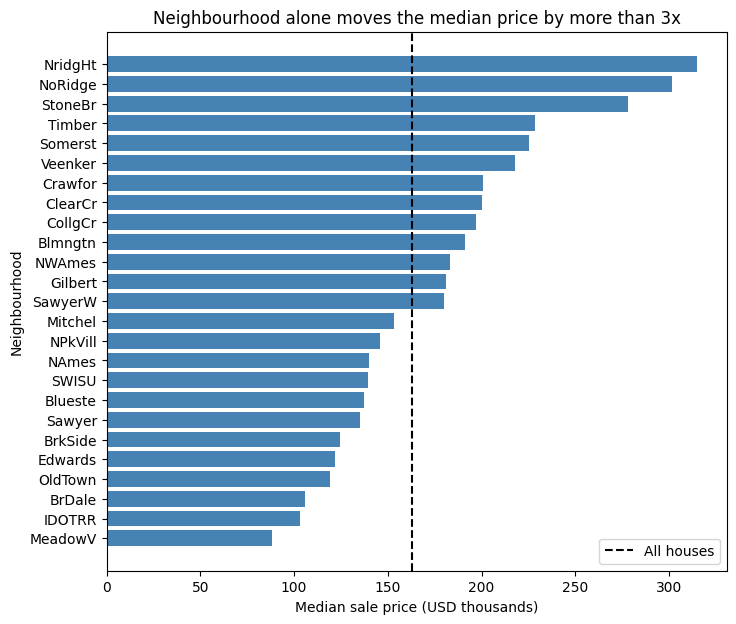

In [15]:
# median, not mean, so a few mansions don't distort a neighbourhood
nbhd = df.groupby("Neighborhood")["SalePrice"].median().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(nbhd.index, nbhd.values / 1000, color="steelblue")
ax.axvline(df["SalePrice"].median() / 1000, color="black", linestyle="--", label="All houses")
ax.set_title("Neighbourhood alone moves the median price by more than 3x")
ax.set_xlabel("Median sale price (USD thousands)")
ax.set_ylabel("Neighbourhood")
ax.legend()
plt.show()

**What I see**
- Quality: each step up adds more money than the step before, which fits a log target.
- Neighbourhood: MeadowV is the cheapest, NridgHt/NoRidge the most expensive. Location matters even for similar houses, so Neighborhood must go into the model as a category.